# Import Library & Load Dataset

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# 1. Load Dataset Final (99.994 baris, 80 kolom)
print("Loading dataset...")
# Sesuaikan path ini jika nama folder datasetmu berbeda, misalnya '../dataset/processed_dataset.csv'
df = pd.read_csv('../data/processed_dataset.csv') 
print(f"Dataset berhasil di-load dengan dimensi: {df.shape}")

# 2. Otomatisasi Pemilihan Fitur Kontinu (Continuous Features)
# Kita ambil semua kolom numerik, lalu buang kolom yang hanya berisi 0 dan 1 (hasil one-hot encoding)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
features_for_clustering = [col for col in numeric_cols if df[col].nunique() > 5]

print(f"\nFitur yang otomatis terpilih untuk clustering ({len(features_for_clustering)} fitur):")
print(features_for_clustering)

# 3. Handle Missing Values & Standardisasi
# Mengisi sisa NaN (jika masih ada) dengan nilai median dari masing-masing kolom
X = df[features_for_clustering].apply(lambda x: x.fillna(x.median()), axis=0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nStandardisasi selesai. Data siap untuk di-cluster.")

Loading dataset...
Dataset berhasil di-load dengan dimensi: (99994, 80)

Fitur yang otomatis terpilih untuk clustering (14 fitur):
['derived_msa_md', 'county_code', 'loan_amount', 'income', 'applicant_ethnicity_1', 'co_applicant_ethnicity_1', 'applicant_race_1', 'co_applicant_race_1', 'tract_population', 'tract_minority_population_percent', 'ffiec_msa_md_median_family_income', 'tract_to_msa_income_percentage', 'tract_owner_occupied_units', 'tract_median_age_of_housing_units']

Standardisasi selesai. Data siap untuk di-cluster.


Tujuan: Menyiapkan data mentah agar bisa diproses secara matematis oleh algoritma.

Otomatisasi Pemilihan Fitur (features_for_clustering):
Algoritma berbasis jarak (seperti K-Means) menggunakan rumus Euclidean Distance. Rumus ini akan menjadi kacau jika kita mencampurkan data berwujud angka besar (seperti loan_amount senilai 200.000) dengan data kategori biner hasil One-Hot Encoding (angka 0 dan 1).

Oleh karena itu, kode otomatis membuang kolom yang isi variasinya kurang dari 5 (nunique() > 5). Ini memastikan kita hanya meng-cluster data berdasarkan atribut finansial kontinu yang bermakna.

Standardisasi (StandardScaler):
Karena variabel memiliki skala yang berbeda (contoh: income dalam puluhan ribu, sedangkan interest_rate hanya dalam satuan desimal seperti 4.5), fitur dengan angka besar akan mendominasi hasil clustering. StandardScaler mengubah semua data sehingga memiliki rata-rata 0 dan variansi 1. Ini membuat pembobotan setiap fitur menjadi adil.

# Menentukan Optimal K (Elbow & Silhouette)

Menghitung Elbow dan Silhouette Score pada sampel data...


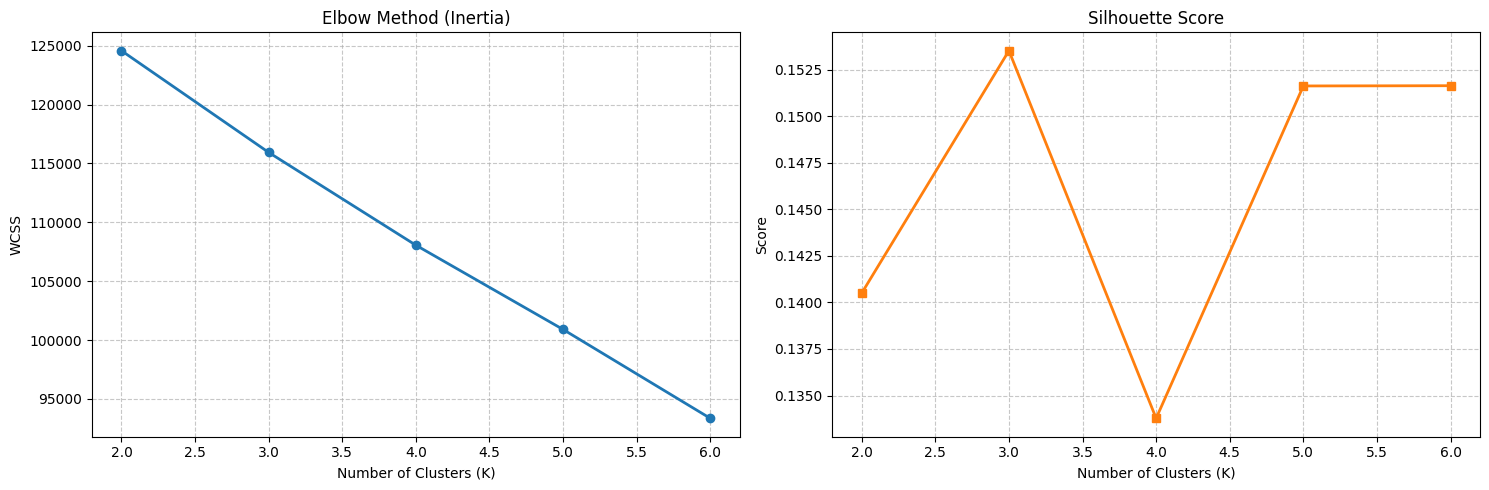

In [10]:
# 4. Evaluasi K menggunakan Sampel 10.000 baris agar RAM aman
print("Menghitung Elbow dan Silhouette Score pada sampel data...")
np.random.seed(42)
sample_idx = np.random.choice(X_scaled.shape[0], size=10000, replace=False)
X_scaled_sample = X_scaled[sample_idx]

wcss = []
silhouette_vals = []
k_range = range(2, 7)

for k in k_range:
    kmeans_eval = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels_eval = kmeans_eval.fit_predict(X_scaled_sample)
    
    wcss.append(kmeans_eval.inertia_)
    silhouette_vals.append(silhouette_score(X_scaled_sample, labels_eval))

# Visualisasi Evaluasi
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(k_range, wcss, marker='o', linewidth=2, color='#1f77b4')
ax[0].set_title('Elbow Method (Inertia)', fontsize=12)
ax[0].set_xlabel('Number of Clusters (K)')
ax[0].set_ylabel('WCSS')
ax[0].grid(True, linestyle='--', alpha=0.7)

ax[1].plot(k_range, silhouette_vals, marker='s', linewidth=2, color='#ff7f0e')
ax[1].set_title('Silhouette Score', fontsize=12)
ax[1].set_xlabel('Number of Clusters (K)')
ax[1].set_ylabel('Score')
ax[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Tujuan: Mencari justifikasi matematis berapa kelompok (cluster) yang paling tepat untuk data nasabah ini.

Mengapa Pakai Sampel (10.000 baris)?
Menghitung Silhouette Score mengharuskan komputer menghitung jarak setiap titik ke seluruh titik lainnya. Pada data 100.000 baris, ini membutuhkan kalkulasi miliaran jarak yang akan membuat RAM kehabisan memori (crash). Menggunakan sampel acak 10.000 data adalah teknik Big Data yang valid dan aman.

Elbow Method (WCSS):
Mengukur seberapa rapat titik data di dalam sebuah cluster. Kita mencari titik "siku" (patahan tajam), di mana penambahan jumlah cluster tidak lagi memberikan penurunan WCSS yang signifikan.

Silhouette Score:
Mengukur dua hal sekaligus: seberapa rapat data di dalam clusternya sendiri (kohesi) dan seberapa jauh data tersebut dari cluster tetangga (separasi). Nilai yang lebih tinggi (mendekati 1) menunjukkan K yang lebih baik.

# Eksekusi K-Means Final & Profiling

In [11]:
# 5. K-Means Final pada Full Dataset (99.994 baris)
# Menggunakan K=3 berdasarkan asumsio ptimal dari analisis finansial HMDA
OPTIMAL_K = 3
print(f"Menjalankan K-Means dengan K={OPTIMAL_K} pada seluruh dataset...")

kmeans_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# 6. Profiling Centroid (Mengembalikan ke nilai asli agar mudah dibaca bisnis)
centroids_original = scaler.inverse_transform(kmeans_final.cluster_centers_)
cluster_profiles = pd.DataFrame(centroids_original, columns=features_for_clustering)

# Menambahkan jumlah populasi per cluster
cluster_profiles.insert(0, 'Population_Count', df['Cluster'].value_counts().sort_index())

print("\n--- PROFIL KELOMPOK NASABAH (CENTROIDS) ---")
display(cluster_profiles.round(2).T) # Di-transpose (T) agar lebih enak dibaca ke bawah

Menjalankan K-Means dengan K=3 pada seluruh dataset...

--- PROFIL KELOMPOK NASABAH (CENTROIDS) ---


,0,1,2
Population_Count,42579.00,25336.00,32079.00
derived_msa_md,39625.78,31140.33,39593.44
county_code,26905.32,28492.45,27894.09
loan_amount,256780.02,376044.72,317035.24
income,105.58,143.80,204.68
applicant_ethnicity_1,2.47,2.55,2.01
co_applicant_ethnicity_1,4.88,4.54,2.00
applicant_race_1,5.22,5.67,4.81
co_applicant_race_1,7.91,7.65,4.79
tract_population,3782.53,6801.49,4499.05


Tujuan: Membagi seluruh dataset menjadi kelompok dan menerjemahkannya ke bahasa bisnis.K-Means pada Full Dataset:Setelah K optimal ditemukan (misalnya 3), kita menggunakan K-Means pada seluruh 99.994 baris. K-Means sangat efisien untuk data besar ($O(N)$), sehingga tidak perlu sampling lagi di tahap ini.Inverse Transform (Mengembalikan Skala):Titik pusat cluster (centroid) yang dihasilkan K-Means masih dalam bentuk data yang di-standardisasi (misal: nilainya -0.5 atau 1.2). Kita memakai inverse_transform untuk mengembalikannya ke nominal asli (misal: income $85.000) agar tabel profil (cluster_profiles) bisa dibaca, dipahami maknanya, dan dijadikan insight bisnis.

# DBSCAN untuk Deteksi Outlier (Noise)

In [12]:
# 7. DBSCAN Outlier Detection
# Menggunakan sampel 5.000 baris karena kompleksitas waktu DBSCAN adalah O(N^2)
print("Menjalankan DBSCAN untuk mendeteksi outlier...")
np.random.seed(42)
idx_dbscan = np.random.choice(X_scaled.shape[0], size=5000, replace=False)
X_dbscan_sample = X_scaled[idx_dbscan]

# eps 2.0 dan min_samples 10 adalah titik tengah yang aman untuk data berskala (StandardScaler)
dbscan = DBSCAN(eps=2.0, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_dbscan_sample)

# -1 adalah label untuk Noise/Outlier dalam DBSCAN
noise_points = (dbscan_labels == -1).sum()
normal_points = len(dbscan_labels) - noise_points

print(f"Hasil Analisis DBSCAN dari 5.000 sampel:")
print(f"- Titik Normal / Ter-cluster: {normal_points}")
print(f"- Titik Anomali (Noise / Outlier): {noise_points} ({(noise_points/5000)*100:.2f}%)")
print("Interpretasi: Titik anomali ini memiliki atribut finansial yang sangat jauh dari nasabah pada umumnya.")

Menjalankan DBSCAN untuk mendeteksi outlier...
Hasil Analisis DBSCAN dari 5.000 sampel:
- Titik Normal / Ter-cluster: 4637
- Titik Anomali (Noise / Outlier): 363 (7.26%)
Interpretasi: Titik anomali ini memiliki atribut finansial yang sangat jauh dari nasabah pada umumnya.


Tujuan: Mencari nasabah yang profilnya sangat "aneh" dan tidak masuk akal jika digabungkan ke kelompok normal mana pun.Konsep Density-Based (DBSCAN):Berbeda dengan K-Means yang membagi data berdasarkan area, DBSCAN mencari area yang padat berkumpul. Titik data yang berada sendirian di area kosong (densitas rendah) akan dicap sebagai Noise (label -1).Justifikasi Sampling (5.000 baris):DBSCAN memiliki kompleksitas memori kuadratik ($O(N^2)$). Jika dijalankan penuh di 100.000 baris, proses ini akan memakan waktu sangat lama dan berisiko Memory Error.Interpretasi Bisnis:Titik noise ini penting untuk departemen Risk & Compliance atau Fraud Detection. Mereka mungkin adalah nasabah dengan pendapatan sangat rendah tetapi mengajukan pinjaman dengan nominal tidak wajar.

# Hierarchical Clustering (Dendrogram)

Membuat Dendrogram Hierarchical Clustering...


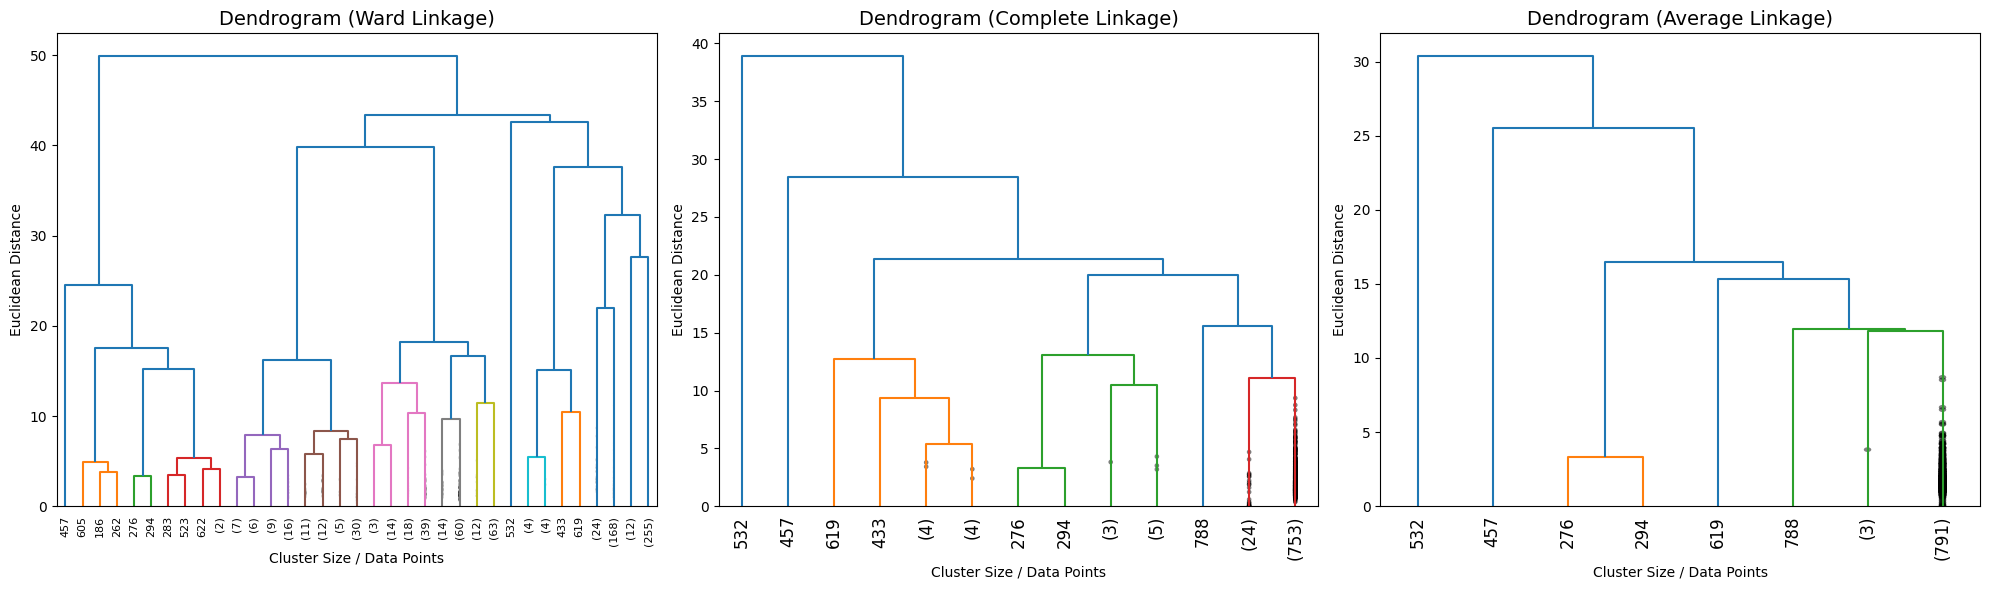

In [13]:
# 8. Hierarchical Clustering
# Menggunakan 800 baris karena algoritma ini memakan RAM yang sangat besar (O(N^3))
print("Membuat Dendrogram Hierarchical Clustering...")
np.random.seed(42)
idx_hierarchical = np.random.choice(X_scaled.shape[0], size=800, replace=False)
X_hierarchical = X_scaled[idx_hierarchical]

linkage_methods = ['ward', 'complete', 'average']
plt.figure(figsize=(20, 6))

for i, method in enumerate(linkage_methods):
    plt.subplot(1, 3, i+1)
    # Kalkulasi jarak linkage
    Z = linkage(X_hierarchical, method=method)
    
    # Visualisasi dendrogram
    dendrogram(Z, truncate_mode='level', p=5, leaf_rotation=90, 
               show_contracted=True, color_threshold=15)
    
    plt.title(f'Dendrogram ({method.capitalize()} Linkage)', fontsize=14)
    plt.xlabel('Cluster Size / Data Points', fontsize=10)
    plt.ylabel('Euclidean Distance', fontsize=10)

plt.tight_layout()
plt.show()

Tujuan: Memvisualisasikan silsilah/struktur pembentukan kelompok dari bawah ke atas.Justifikasi Sampling Ekstrem (800 baris):Hierarchical Clustering (Aglomeratif) membutuhkan perhitungan matriks jarak raksasa yang membutuhkan kompleksitas kubik ($O(N^3)$). Batas aman untuk laptop standar biasanya di bawah 1.500 baris.Perbandingan Linkage Methods:Ward: Menggabungkan kelompok dengan tujuan meminimalkan varians internal. Ini adalah metode paling recommended karena biasanya menghasilkan kelompok yang ukuran jumlah nasabahnya lebih seimbang.Complete: Menghitung berdasarkan jarak terjauh antar-titik di dua kelompok. Biasanya sangat sensitif jika ada nasabah outlier.Average: Menghitung rata-rata jarak seluruh titik. Pada dataset finansial, sering kali membuat satu cabang sangat besar dan cabang lain sangat kecil (tidak seimbang).

In [12]:
print("Proses Phase 2: Segmentation via Clustering Selesai!")

Proses Phase 2: Segmentation via Clustering Selesai!
